## Simulation

Small notebook to run the simulation and see what is happening

#### TFIM Local magnetization

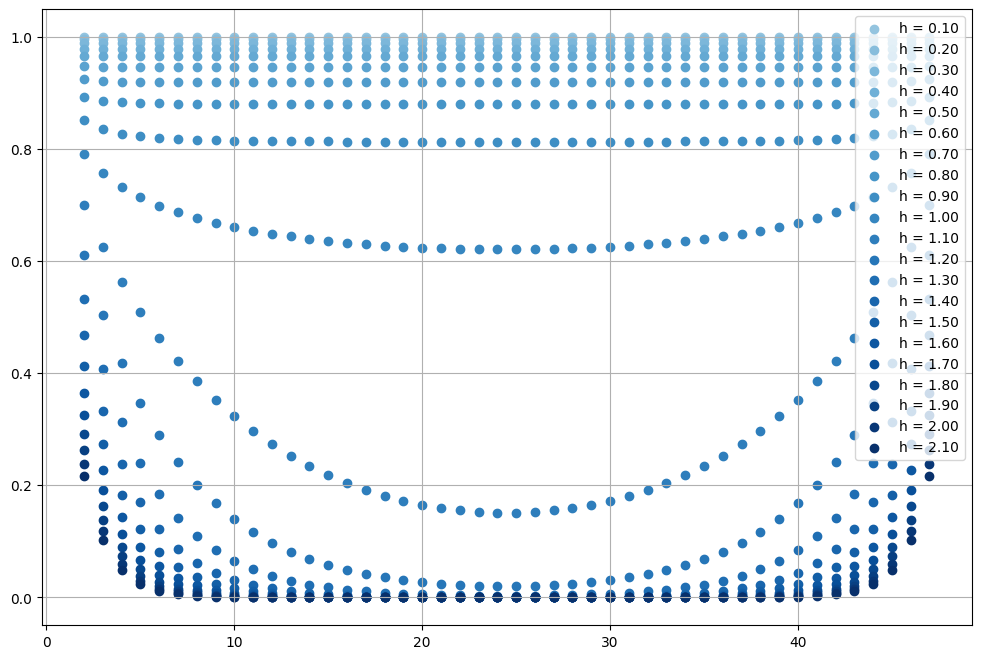

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

home = os.getcwd()
os.chdir("..")

outputs = os.path.join(os.getcwd(), "OUT/TFIM")
cor = cm.Blues(np.linspace(0.4, 1, 21))
values = []
values2 = []
h_indices = []
plt.figure(figsize=(12, 8))

for index, h_value in enumerate(sorted(os.listdir(outputs))):
    result = os.path.join(outputs, h_value)

    arr = np.loadtxt(os.path.join(result, "Z.txt")).T
    arr2 = np.loadtxt(os.path.join(result, "S.txt")).T
    values.append(min(arr[1]))
    values2.append(max(arr2[2]))
    h_indices.append(h_value.split("_")[1])
    plt.scatter(arr[0], arr[1], color=cor[index], label=f"h = {h_value.split("_")[1]}")


plt.legend(loc="upper right")
plt.grid()
plt.show()

os.chdir(home)

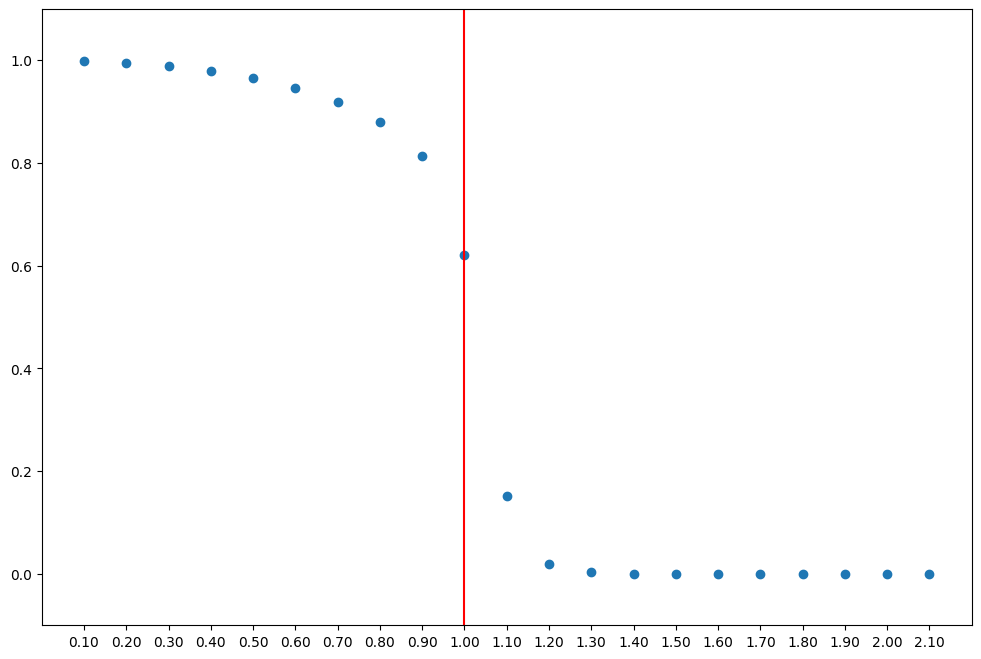

In [3]:
plt.figure(figsize=(12, 8))
plt.scatter(h_indices, values, label="L = 50")
plt.ylim((min(values)-.1, max(values)+.1))
plt.vlines(9, min(values)-.1, max(values)+.1, colors='red')

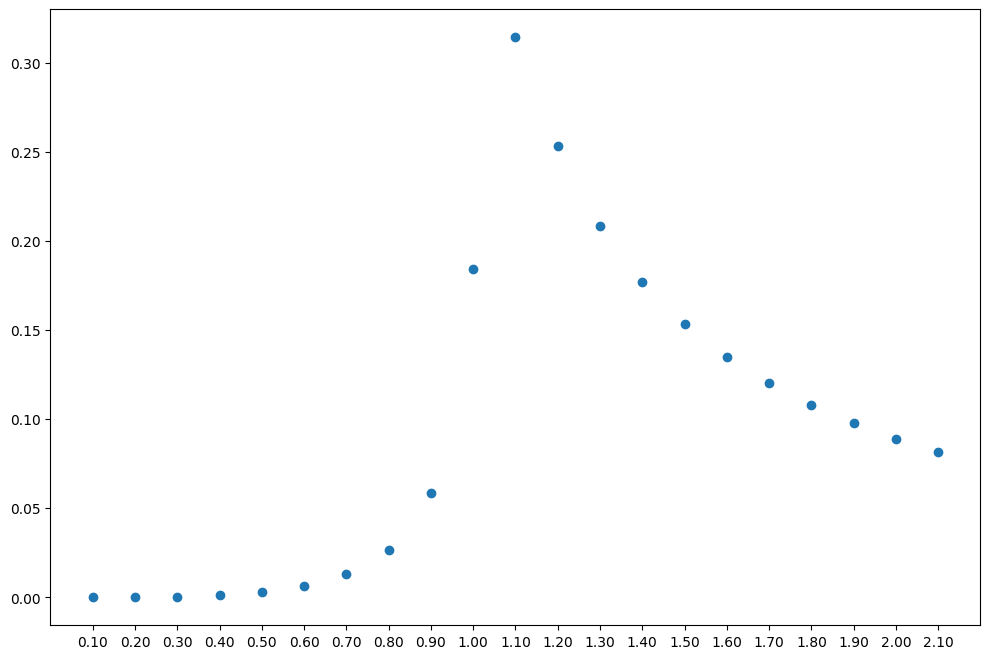

In [6]:
plt.figure(figsize=(12, 8))
plt.scatter(h_indices, values2, label="L = 50")
# plt.ylim((min(values)-.1, max(values2)+.1))
# plt.vlines(9, min(values)-.1, max(values)+.1, colors='red')

#### Data processing of values - Open BC

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# change home directory to OUT
home = os.getcwd()
os.chdir("..")
dir = os.path.join(os.getcwd(), "OUT/First_Run")

# extract data
h_values = np.arange(0, 2.1, 0.2)
k_values = np.arange(-2, 2.1, 0.2)
results = np.zeros((len(h_values), len(k_values)))
results2 = np.zeros((len(h_values), len(k_values)))
woops = []
for ind, file in enumerate(os.listdir(dir)):
    name = file.split("_")
    
    h = float(name[1])
    h = float(name[2])
    h_idx = np.where(np.isclose(h_values, h, atol=1e-8))[0][0]
    k_idx = np.where(np.isclose(k_values, h, atol=1e-8))[0][0]

    loc = os.path.join(dir, file)
    magnetization = np.loadtxt(os.path.join(loc, "Z.txt")).T
    results[h_idx][k_idx] = min(magnetization[1])
    entropy = np.loadtxt(os.path.join(loc, "S.txt")).T
    results2[h_idx][k_idx] = max(entropy[2])

    # check convergence
    E = np.loadtxt(os.path.join(loc, "E_sweep.txt")).T

    if not np.isclose(E[-1], E.min(), atol=1e-8):
        woops.append([h, h])

# reset the home directory after each run
os.chdir(home)

##### Checking for convergence

In [9]:
# all parameter points that dont converge well
woops = np.array(woops)
if woops.shape == (0,):
    print("Everything converged!")
else:
    plt.scatter(woops[1], woops[0])

Everything converged!


##### Magnetization Plotting

##### Plotting via imshow

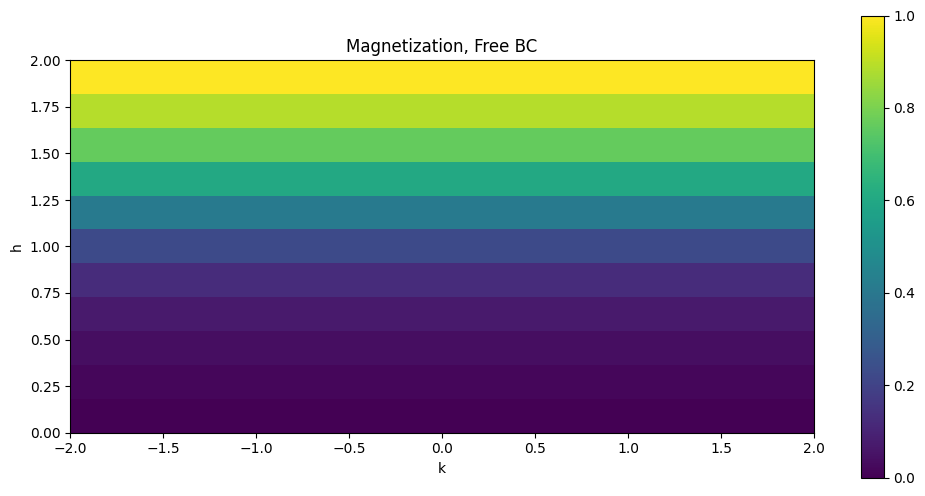

In [5]:
from matplotlib import cm
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(results, interpolation='none', extent=[-2, 2, 0, 2])
fig.colorbar(cm.ScalarMappable(), ax=ax)
ax.set_title("Magnetization, Free BC")
ax.set_xlabel("k")
ax.set_ylabel('h')
plt.show()

# plt.imshow(results)

##### Entanglement Entropy

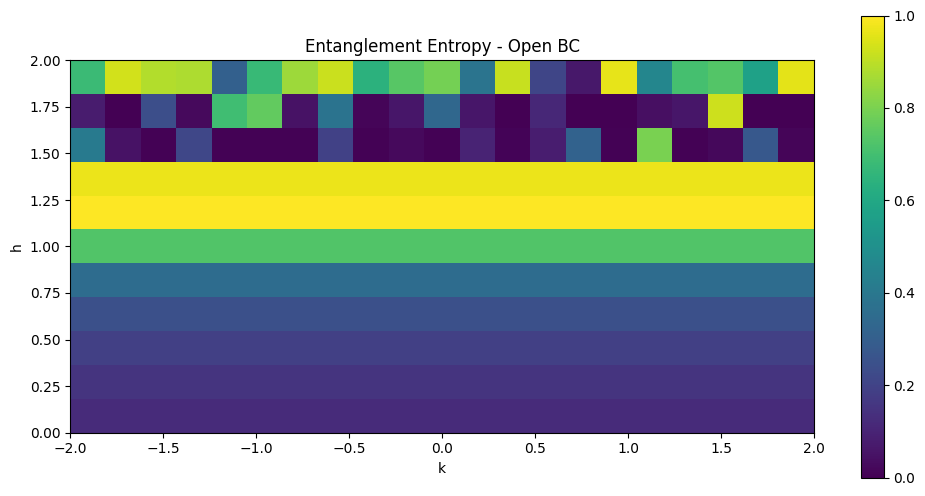

In [36]:
from matplotlib import cm
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(results2, interpolation='none', extent=[-2, 2, 0, 2])
fig.colorbar(cm.ScalarMappable(), ax=ax)
ax.set_xlabel("k")
ax.set_ylabel('h')
ax.set_title("Entanglement Entropy - Open BC")
plt.show()


#### Data processing - Fixed X Polarization

In [52]:
import os
import numpy as np
import matplotlib.pyplot as plt

# change home directory to OUT
L = 16
k = 0.3

dir = os.path.join(os.getcwd(), f"0_0/OUT")

magnetization = []
k_values = []
# magnetization_real = np.zeros(len(h_values))
# magnetization_img = np.zeros(len(h_values))
# entropy = np.zeros(len(h_values))

for ind, file in enumerate(sorted(os.listdir(dir))):
    name = file.split("_")
    h = float(name[1])
    k = float(name[2])

    loc = os.path.join(dir, file)

    m = np.loadtxt(os.path.join(loc, "X.txt"))
    # only take central ones
    magnetization.append((m[10][1] - m[9][1]))
    k_values.append(h)


    # s = np.loadtxt(os.path.join(loc, "S.txt"))
    # entropy[h_idx] = (s[10][1] + m[9][1])

    # check convergence
    E = np.loadtxt(os.path.join(loc, "E_sweep.txt")).T

    if not np.isclose(E[-1], E.min(), atol=1e-8):
        woops.append([h, h])



## Magnetization

#### Magnetization of central sites against values of h/k

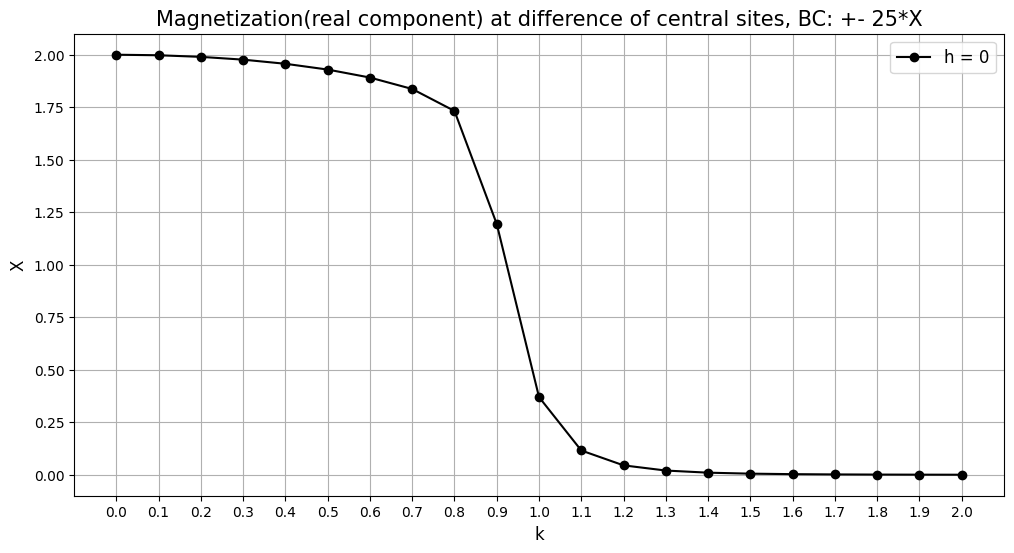

In [53]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(k_values, magnetization, c='black', marker='o', label="h = 0")

ax.set_title("Magnetization(real component) at difference of central sites, BC: +- 25*X", size=15)
ax.set_xlabel("k", size=12)
ax.set_ylabel('X', size=12)
ax.set_xticks(k_values)
plt.legend(fontsize=12)
plt.grid()
plt.show()

#### Magnetization along string at (h, k)

#### Sanity Check - Duality of (0.5, 0.0) and (2.0, 0.0)

/home/silvanita/Desktop/thesis/master_thesis/venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/silvanita/Desktop/thesis/master_thesis/venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


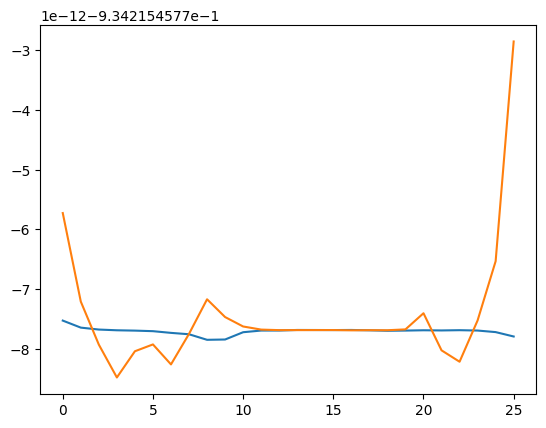

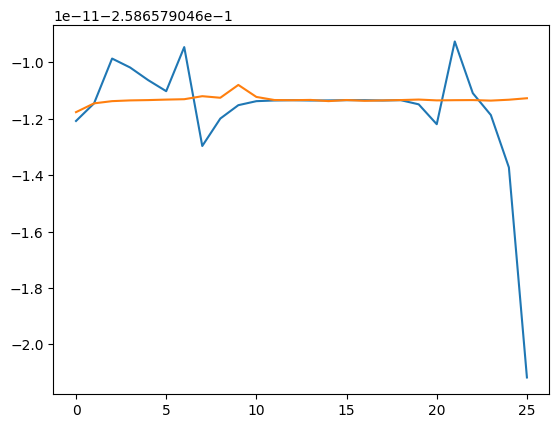

In [ ]:
import os 
import numpy as np
import matplotlib.pyplot as plt
path = os.path.join(os.getcwd(), "TFIM_60")

firstXX = os.path.join(path, "out_0.50_0.00", "XX.txt")
firstZ = os.path.join(path, "out_0.50_0.00", "Z.txt")
secondXX = os.path.join(path, "out_2.00_0.00", "XX.txt")
secondZ = os.path.join(path, "out_2.00_0.00", "Z.txt")

readxx1, readxx2 = np.loadtxt(firstXX, dtype=complex), np.loadtxt(secondXX, dtype=complex)
XX1, XX2 = [], []
for entry in readxx1:
    if entry[1] - entry[0] == 1:
        XX1.append(entry[2])

for entry in readxx2:
    if entry[1] - entry[0] == 1:
        XX2.append(entry[2])

Z1, Z2 = np.loadtxt(firstZ, dtype=complex).T[1], np.loadtxt(secondZ, dtype=complex).T[1]




/home/silvanita/Desktop/thesis/master_thesis/venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/silvanita/Desktop/thesis/master_thesis/venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


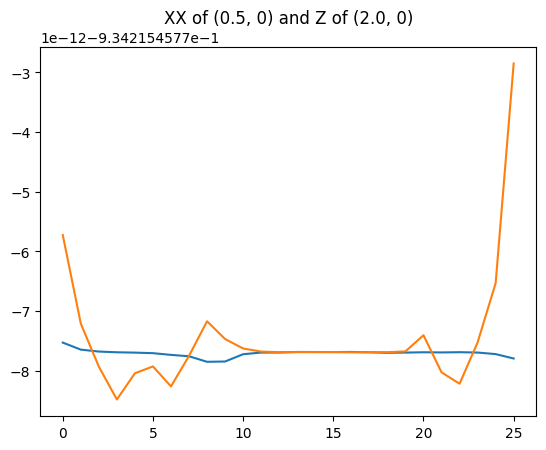

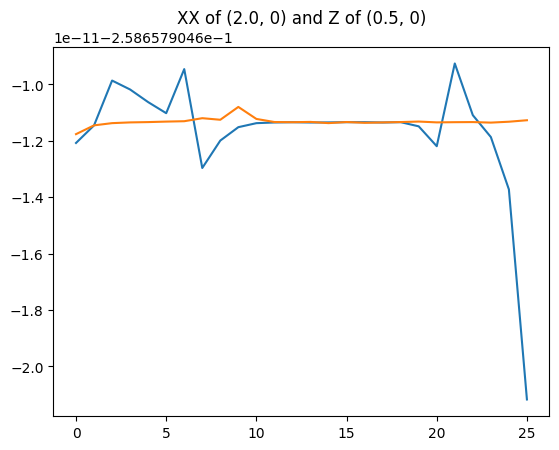

In [36]:
cut = 15
plt.plot(XX1[cut:-cut])
plt.plot(Z2[cut:-cut])
plt.title("XX of (0.5, 0) and Z of (2.0, 0)")
plt.show()

plt.plot(XX2[cut:-cut])
plt.plot(Z1[cut:-cut])
plt.title("XX of (2.0, 0) and Z of (0.5, 0)")
plt.show()


## Entropy

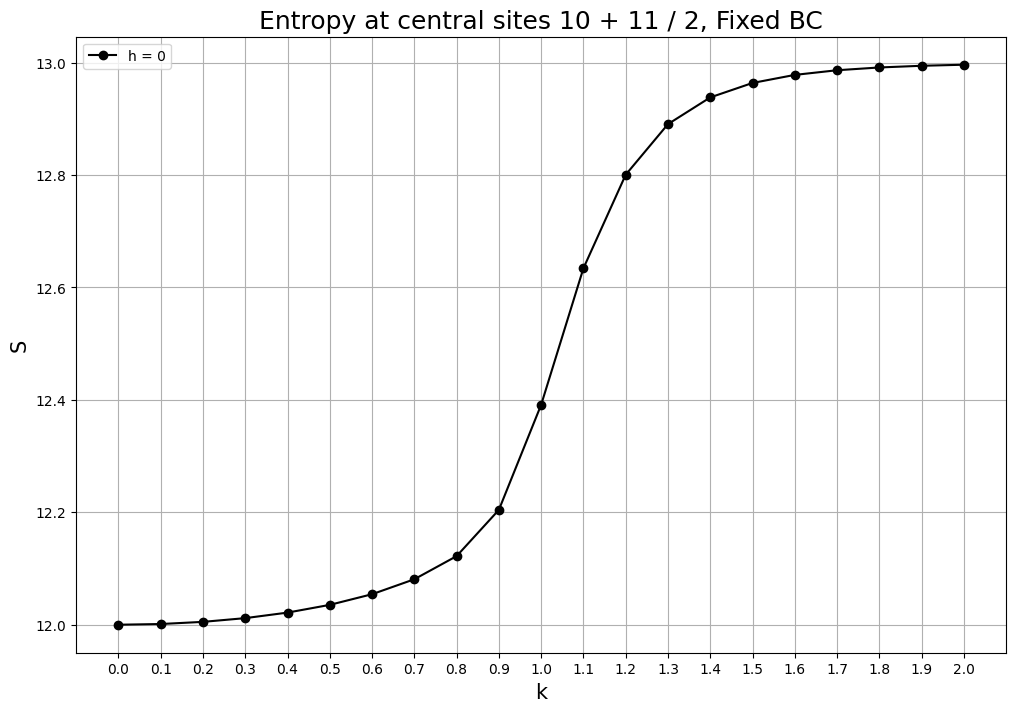

In [55]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(h_values, entropy, c='black', marker='o', label="h = 0")

ax.set_title("Entropy at central sites 10 + 11 / 2, Fixed BC", size=18)
ax.set_xlabel("k", size=15)
ax.set_ylabel('S', size=15)
ax.set_xticks(h_values)
plt.grid()
plt.legend()
plt.show()


## Correlations

##### The next code works on plotting connected correlations
 $$ C(x_i, x_j) = \langle x_i x_j \rangle - \langle x_i\rangle\langle x_j\rangle$$
##### By comparing them against semilogy and log log plots, we can determine if the phase we are looking at is gapped or gapless

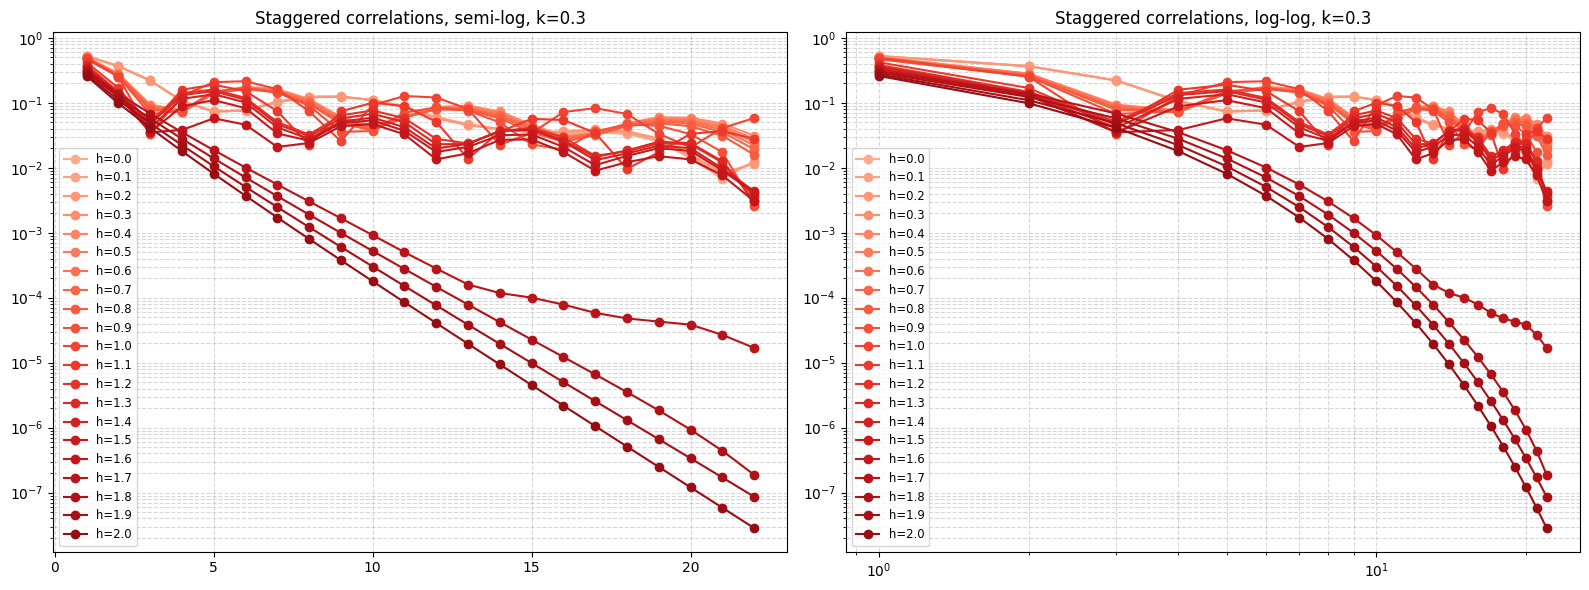

In [32]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

k = 0.3
L = 44
cut = 10

# Paths
path = os.path.join(os.getcwd(), f"out_L={L}/k={k}")
files = sorted(os.listdir(path))
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(files)))

# Create 1 row, 2 columns subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax_semi, ax_log = axes

for count, file in enumerate(files):
    h = float(file.split("_")[1])
    k = float(file.split("_")[2])
    filename = os.path.join(path, f"out_{h:.2f}_{k:.2f}")
    xx_values = np.loadtxt(os.path.join(filename, "XX.txt"), dtype=complex)
    x_values = np.loadtxt(os.path.join(filename, 'X.txt'), dtype=complex).T

    distance = []
    correlation = []
    for i, j, corr in xx_values:
        if i > cut and j < L-cut:
            dist = np.abs(j - i)
            distance.append(dist)
            xi = np.where(np.isclose(x_values[0], i, atol=1e-8))[0][0]
            xj = np.where(np.isclose(x_values[0], j, atol=1e-8))[0][0]

            # Staggered correlation: multiply by (-1)^|i-j|
            staggered_corr = corr - (x_values[1][xi] * x_values[1][xj])
            correlation.append(np.abs(staggered_corr))

    distance = np.array(distance, dtype=int)
    distance = np.minimum(distance, L - distance)
    correlation = np.array(correlation, dtype=float)

    # Average correlations by distance
    groups = defaultdict(list)
    for d, c in zip(distance, correlation):
        groups[d].append(c)
    d_vals = np.array(sorted(groups.keys()))
    avg_corr = np.array([np.mean(groups[d]) for d in d_vals])

    # Plot staggered correlations
    ax_semi.semilogy(d_vals, avg_corr, 'o-', color=colors[count], label=f"h={h}")
    ax_log.loglog(d_vals, avg_corr, 'o-', color=colors[count], label=f"h={h}")

# Titles and grids
ax_semi.set_title(f"Staggered correlations, semi-log, k={k}")
ax_log.set_title(f"Staggered correlations, log-log, k={k}")

for ax in axes:
    ax.legend(fontsize="small")
    ax.grid(which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


## Central Charge - only value at the critical phase


/home/silvanita/Desktop/thesis/master_thesis/books/out_L=60/h=1


/tmp/ipykernel_39707/728334465.py:47: RuntimeWarning: divide by zero encountered in log
  plt.plot(np.log(E_sweep - E_sweep[-1]))
/tmp/ipykernel_39707/728334465.py:47: RuntimeWarning: invalid value encountered in log
  plt.plot(np.log(E_sweep - E_sweep[-1]))


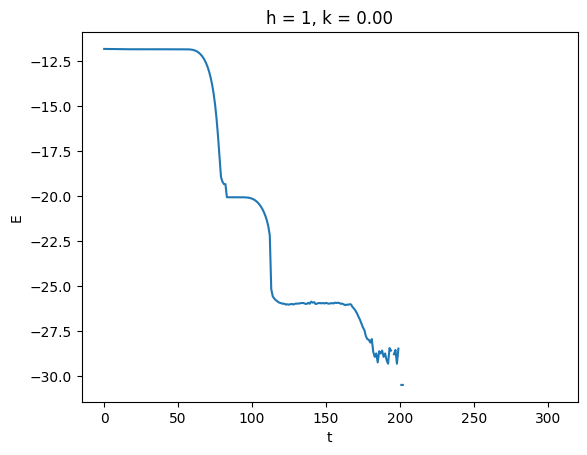

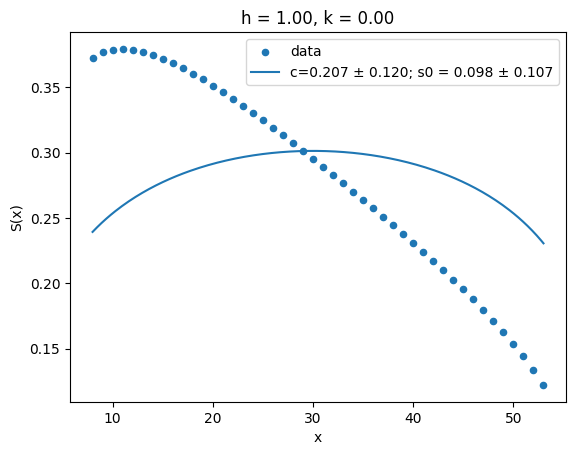

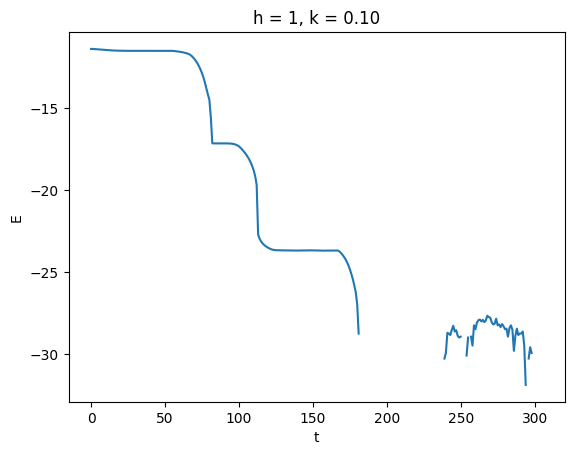

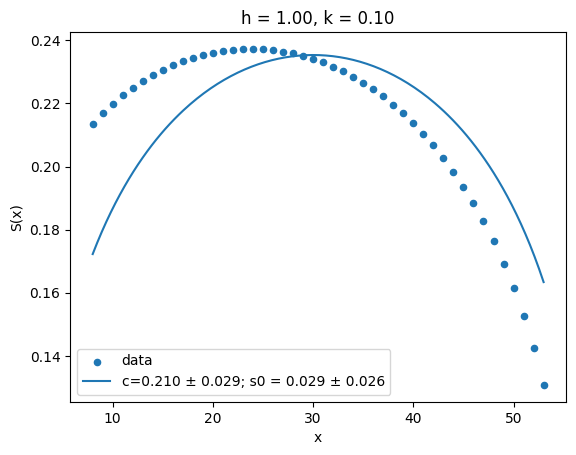

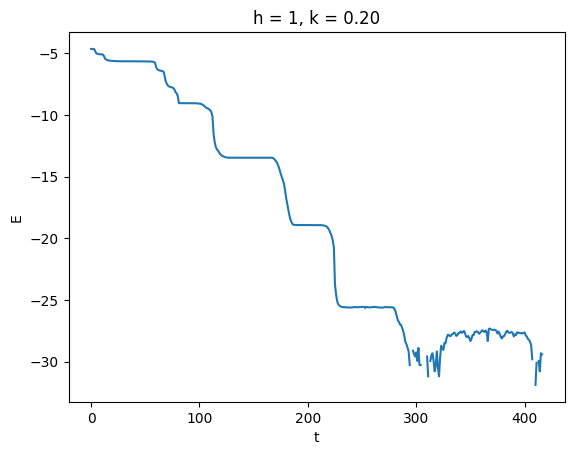

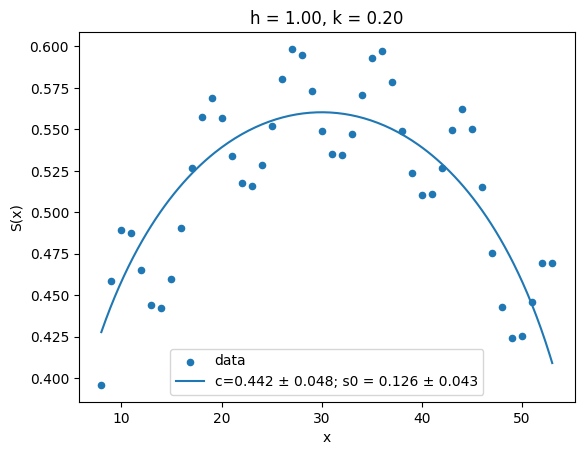

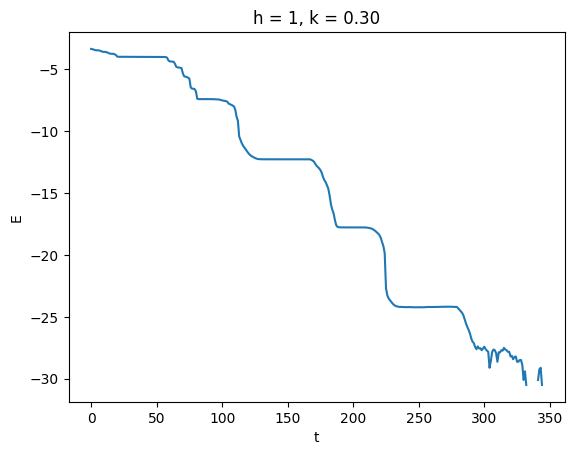

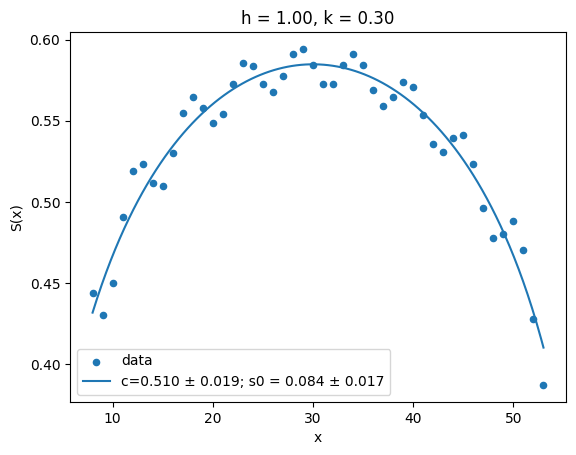

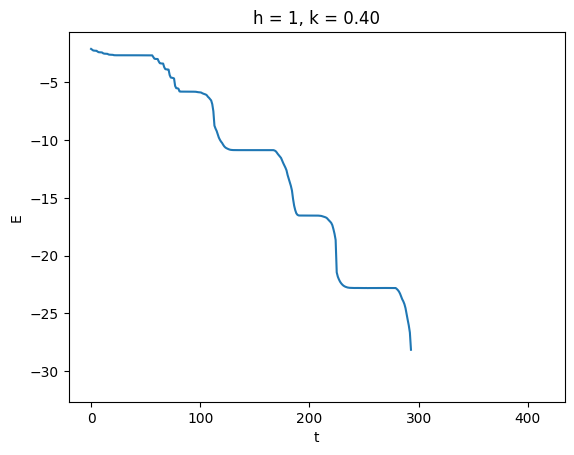

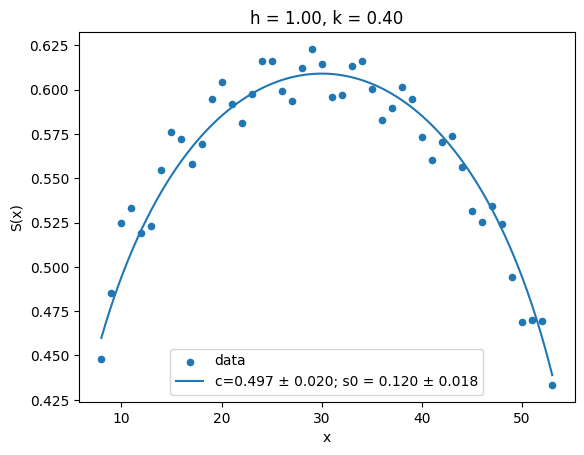

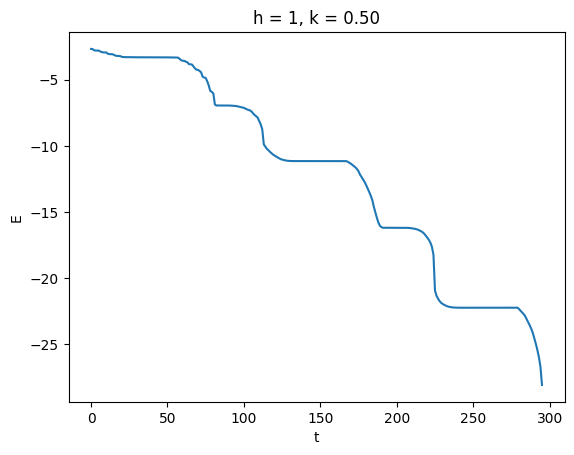

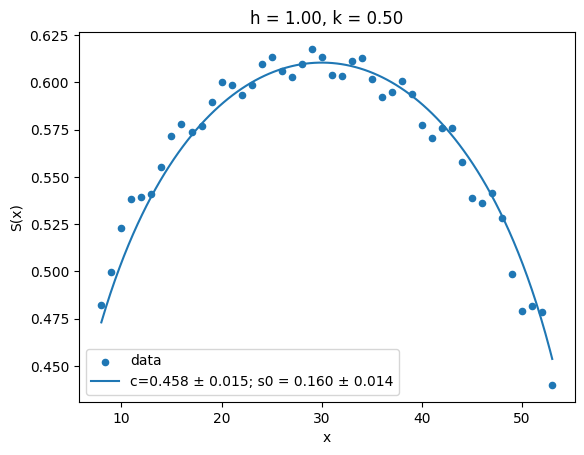

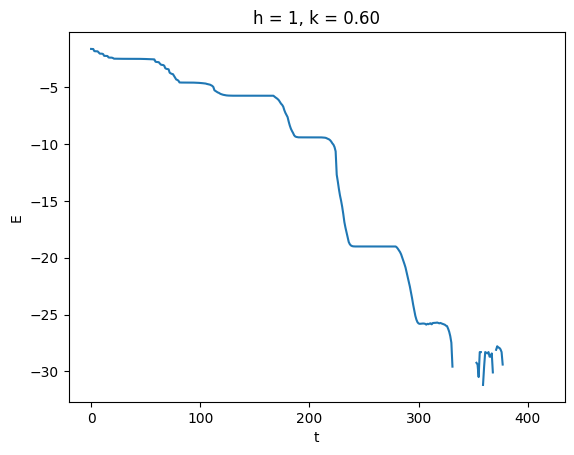

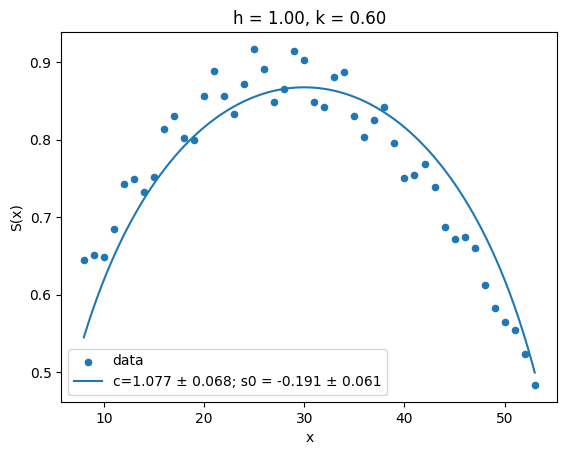

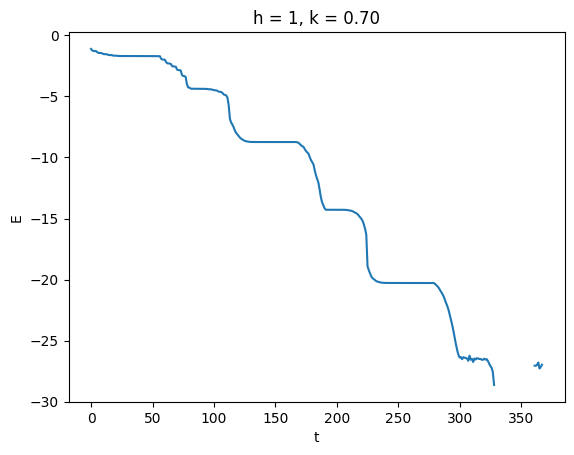

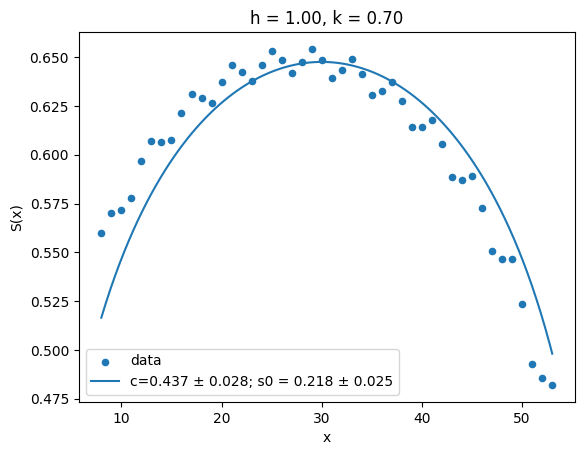

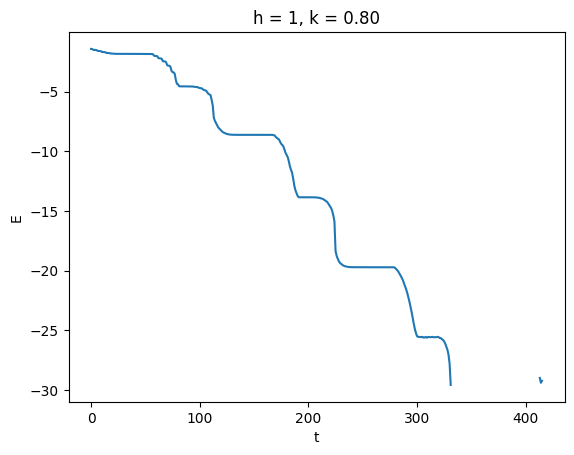

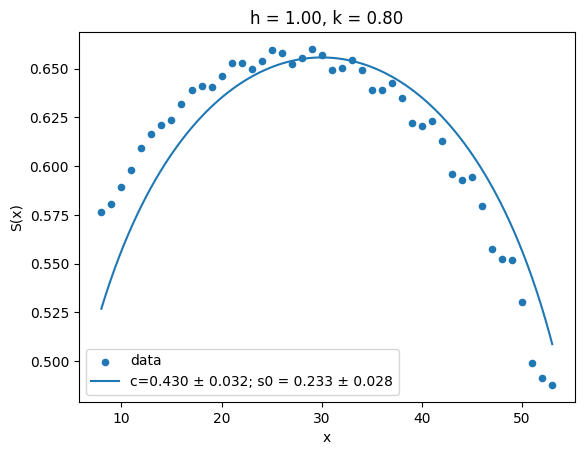

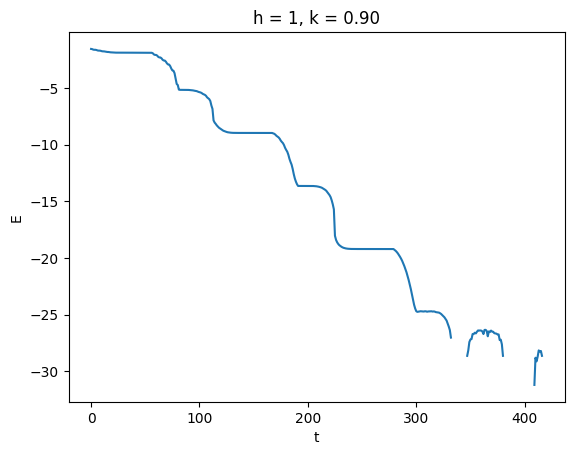

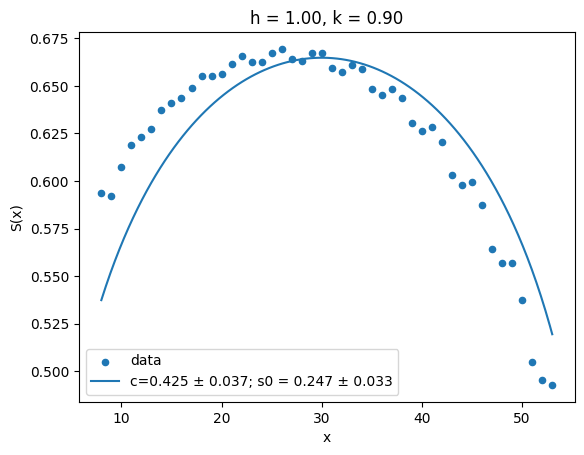

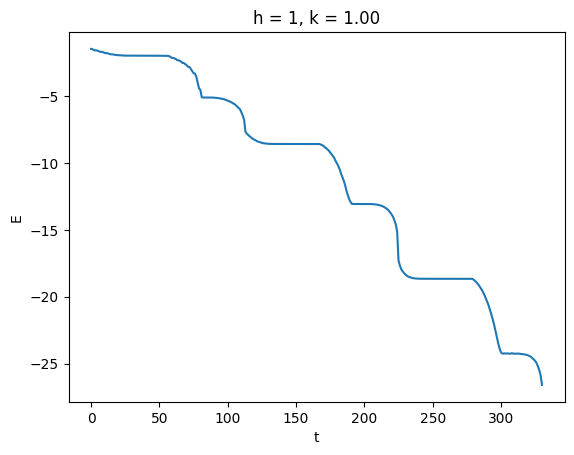

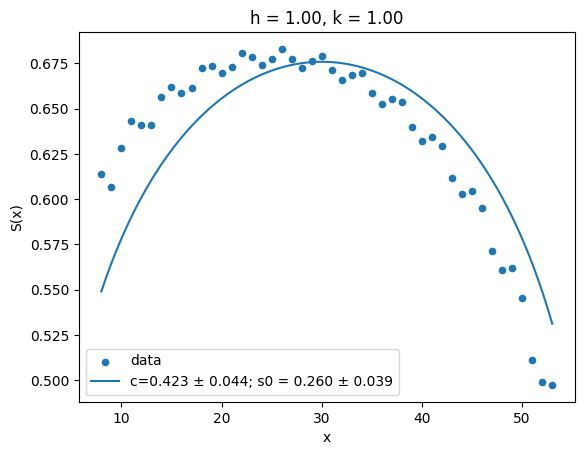

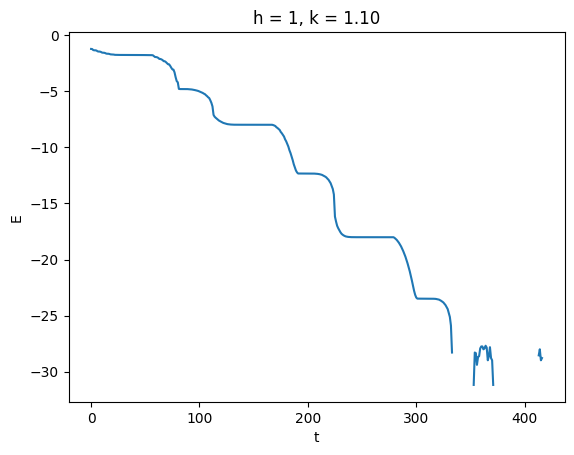

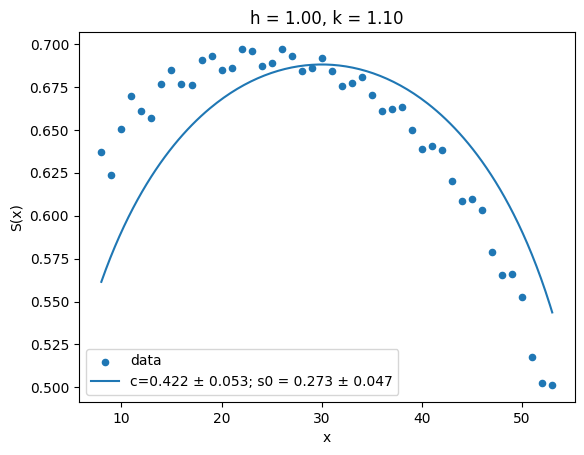

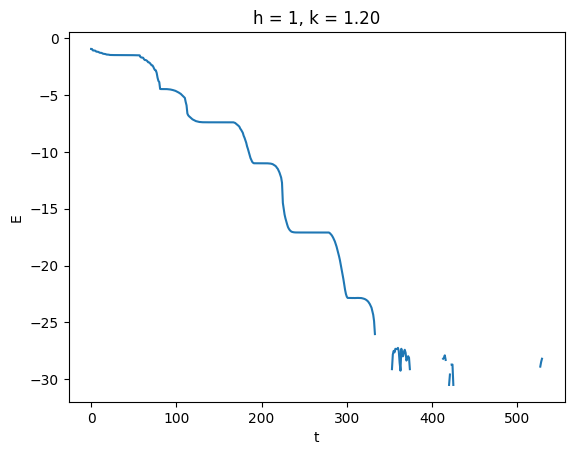

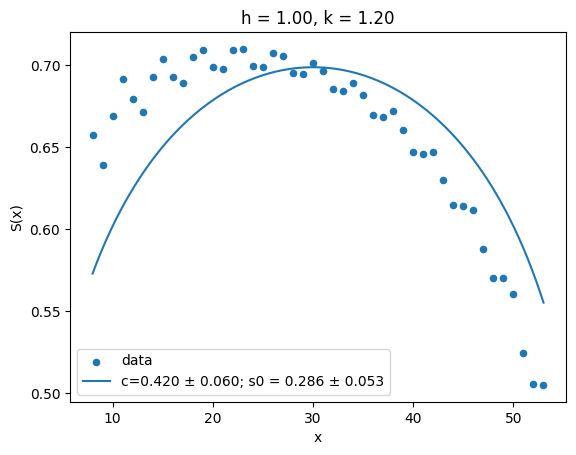

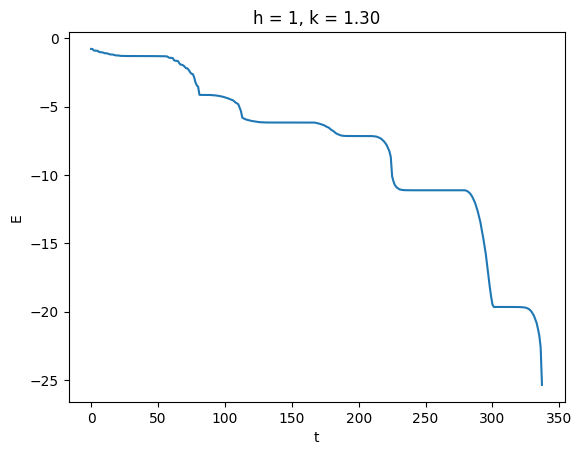

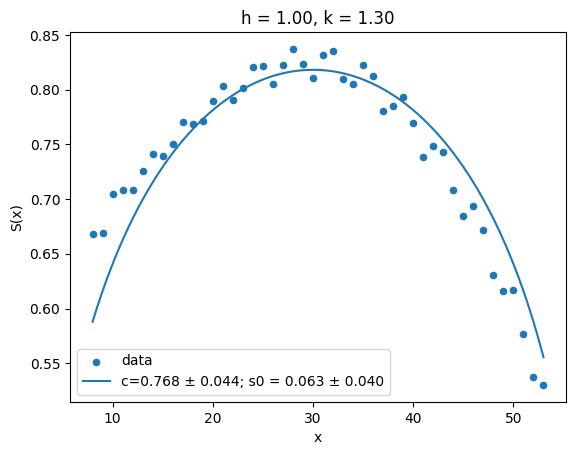

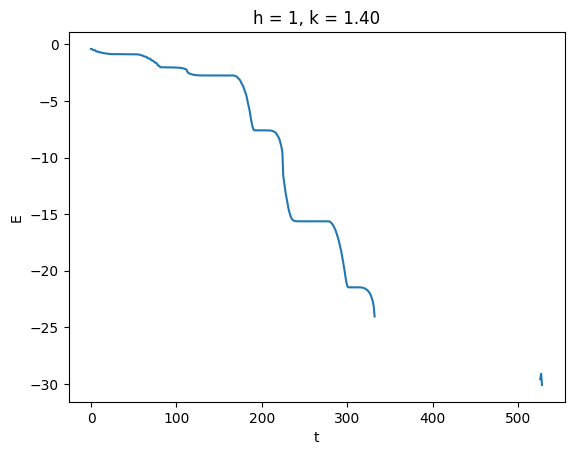

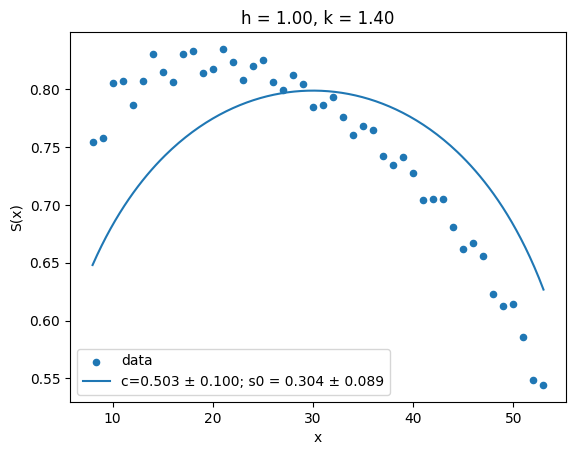

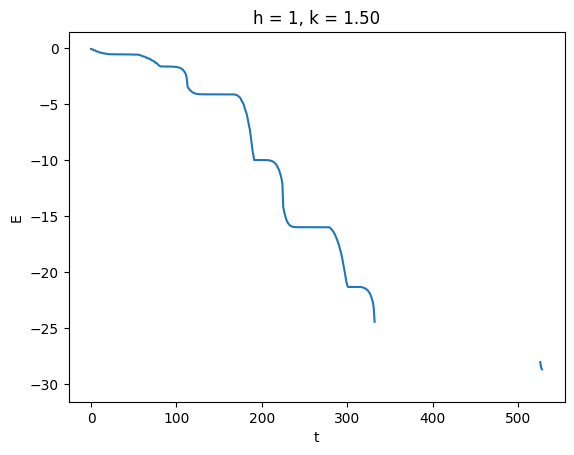

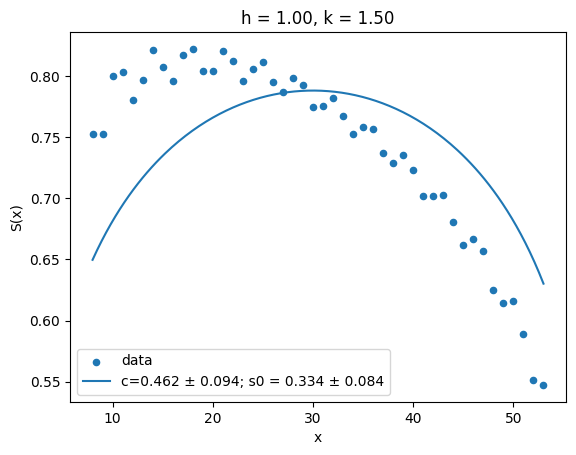

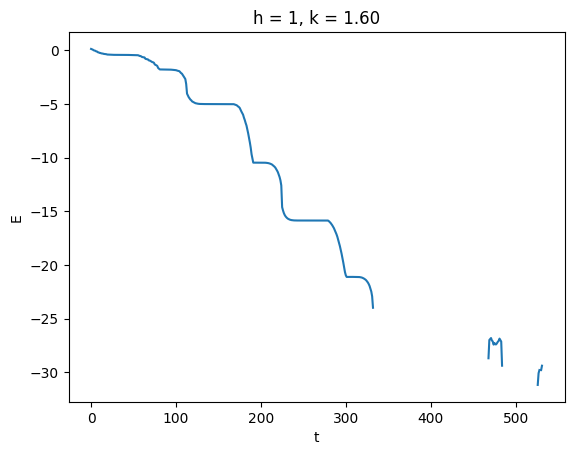

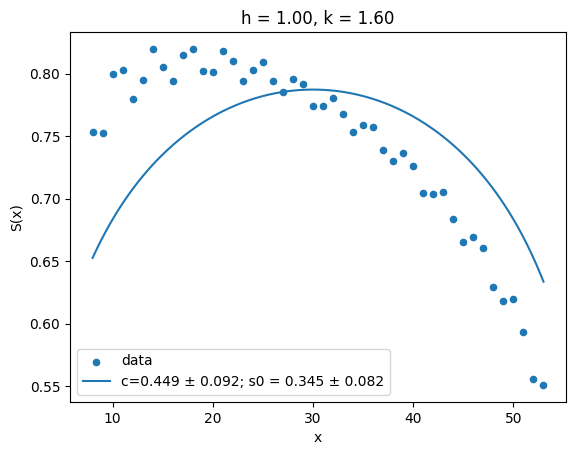

In [48]:
## Calculate central charge from entanglement entropy

from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
import os

L = 60
k_values = 1
def s_calabrese_cardy(x, c, s0):
    return (c/3) * np.log((L / np.pi) * np.sin(np.pi * x / L)) + s0

path = os.path.join(os.getcwd(), f"out_L={L}/h={k_values}")
print(path)
filenames = sorted(os.listdir(path))

h = []
c = []
c_err = []
cut = 5
cols = L - 4 - 2*cut if cut != 0  else L - 4
res = np.zeros((len(filenames), cols))
for index, file in enumerate(filenames):
    _, h1, k1 = file.split("_")
    S = np.loadtxt(os.path.join(path, file, "S.txt")).T
    y0 = np.array(S[2])[cut:-cut] if cut != 0  else np.array(S[2])
    x0 = np.array(S[1])[cut:-cut] if cut != 0  else np.array(S[1])

    p0 = [1, np.mean(y0)]
    bounds = ([0.0, -np.inf], [5.0, np.inf])
    try:
        popt, pcov = curve_fit(s_calabrese_cardy, x0, y0, p0=p0,
                               bounds=bounds, maxfev=10000)
        perr = np.sqrt(np.diag(pcov))
    except Exception as e:
        print(f"Fit failed for {file}: {e}")
        popt = [np.nan, np.nan]
        perr = [np.nan, np.nan]

    h.append(float(k1))
    c.append(popt[0])
    c_err.append(np.sqrt(pcov[0][0]))
    res[index] = y0 - s_calabrese_cardy(x0, *popt)

    E_sweep = np.loadtxt(os.path.join(path, file, 'E_sweep.txt'))
    plt.figure()
    plt.plot(np.log(E_sweep - E_sweep[-1]))
    plt.title(f"h = {k_values}, k = {k1}")
    plt.ylabel("E")
    plt.xlabel("t")
    plt.show()
    
    plt.figure()
    plt.scatter(x0, y0, s=20, label="data")
    xx = np.linspace(x0.min(), x0.max(), 200)
    plt.plot(xx, s_calabrese_cardy(xx, *popt), label=f"c={popt[0]:.3f} ± {perr[0]:.3f}; s0 = {popt[1]:.3f} ± {perr[1]:.3f}")
    plt.title(f"h = {h1}, k = {k1}")
    plt.xlabel("x")
    plt.ylabel("S(x)")
    plt.legend()
    plt.show()



(40,)
(40,)


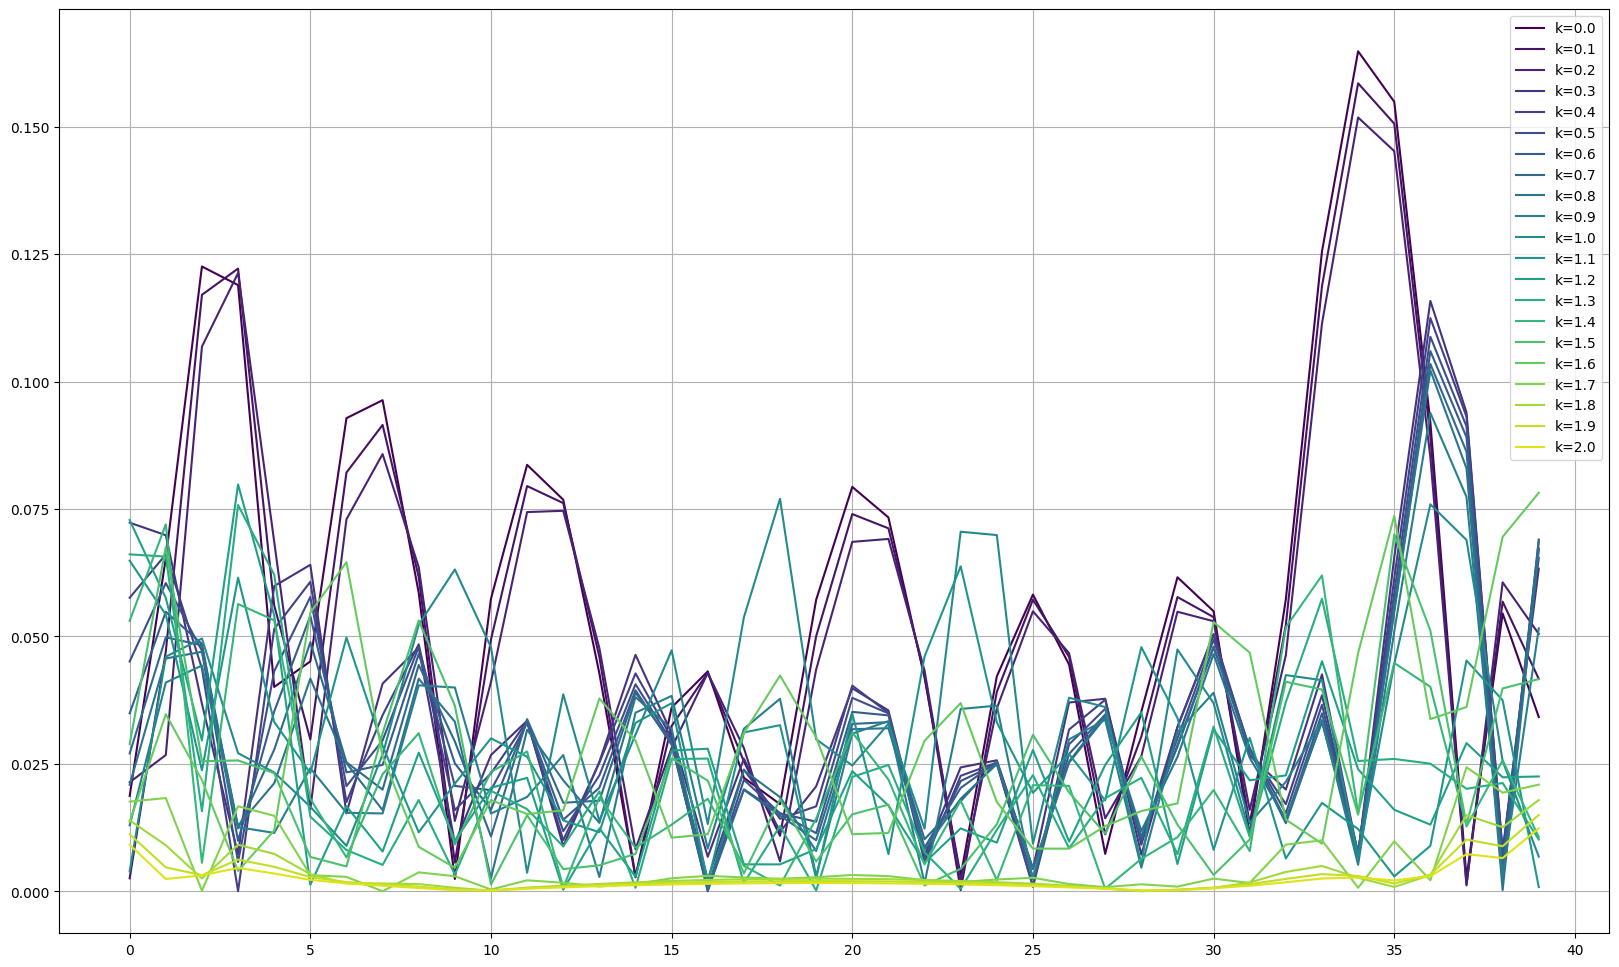

In [5]:
print(np.abs(res[0]).shape)
print(np.arange(len(res[0])).shape)
fig = plt.figure(figsize = (20, 12))

for i in range(len(res)):
    colors = plt.cm.viridis(i / len(res))

    plt.plot(np.arange(0, len(res[i])), np.abs(res[i]), c=colors, label = f"k={i*0.1:.1f}")
plt.legend()
plt.grid()
plt.show()

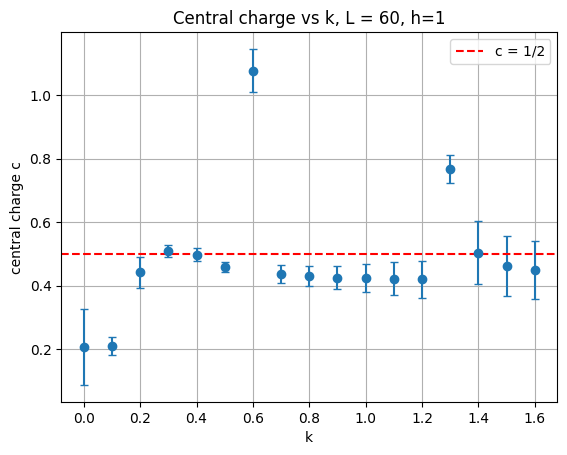

In [45]:
# Make a tidy plot of c vs k (sorted)
hs = np.array(h)
cs = np.array(c)
cs_err = np.array(c_err)
order = np.argsort(hs)
ks_s, cs_s, cs_err_s = hs[order], cs[order], cs_err[order]

plt.figure()
plt.errorbar(ks_s, cs_s, yerr=cs_err_s, fmt='o', capsize=3)
plt.xlabel("k")
plt.ylabel("central charge c")
plt.axhline(0.5, ks_s[0], ks_s[-1], ls = '--', c = 'red', label = "c = 1/2")
plt.title(f"Central charge vs k, L = {L}, h={k_values}")
plt.grid(True)
plt.legend()
plt.show()

## GRAVEYARD

/tmp/ipykernel_4993/2788731697.py:22: ComplexWarning: Casting complex values to real discards the imaginary part
  mean_by_site = {int(row[0]): row[1] for row in X}
/tmp/ipykernel_4993/2788731697.py:25: ComplexWarning: Casting complex values to real discards the imaginary part
  i = int(i_idx); j = int(j_idx)


(h=0.00, k=0.30)  best fit: power-law
  power-law: A=0.246, eta=0.739,  AIC=-50.99
  exponential: A=0.145, xi=8.12, AIC=-49.81


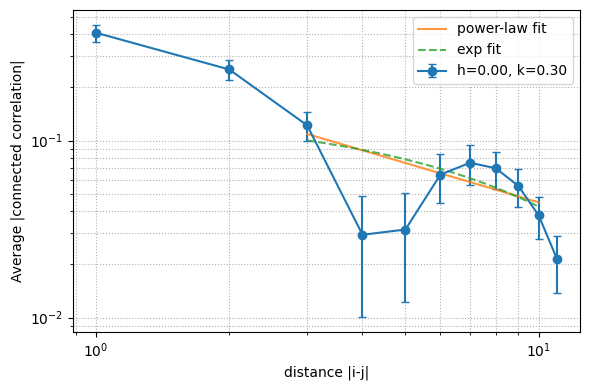

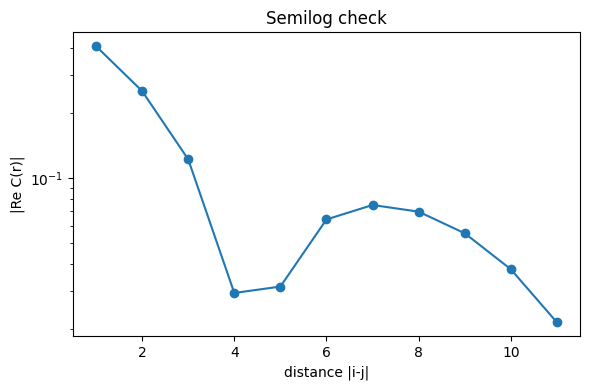

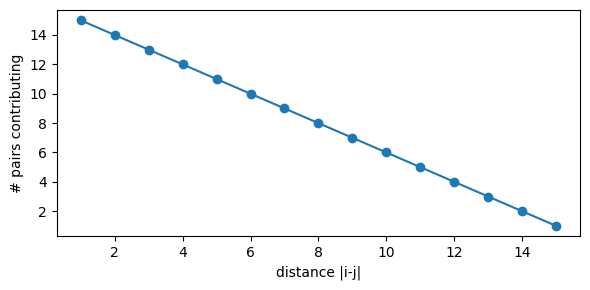

In [ ]:
import os
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.optimize import curve_fit

# --- build: collect all connected correlators by distance for each (h,k) ---
correlations_by_dist = [[defaultdict(list) for _ in range(len(k_values))] for _ in range(len(h_values))]

for h, h in product(h_values, k_values):
    k_idx = int(np.where(np.isclose(k_values, h, atol=1e-8))[0][0])
    h_idx = int(np.where(np.isclose(h_values, h, atol=1e-8))[0][0])

    path = f"out_0_0.5_1/OUT/out_{h:.2f}_{h:.2f}"
    X  = np.loadtxt(os.path.join(os.getcwd(), path, "X.txt" ), dtype="complex")
    XX = np.loadtxt(os.path.join(os.getcwd(), path, "XX.txt"), dtype="complex")

    # Map site index -> <x_i>
    # Assumes X rows are [i, <x_i>]
    # If your indices start at 2 in files, we keep using them directly.
    mean_by_site = {int(row[0]): row[1] for row in X}

    for i_idx, j_idx, xixj in XX:
        i = int(i_idx); j = int(j_idx)
        if i not in mean_by_site or j not in mean_by_site: 
            continue
        xi = mean_by_site[i]
        xj = mean_by_site[j]
        dist = abs(i - j)
        if dist == 0: 
            continue  # skip self-pairs
        corr_val = xixj - (xi * xj)
        correlations_by_dist[h_idx][k_idx][dist].append(corr_val)

# --- choose parameter point to analyze ---

h_idx = int(np.argmin(np.abs(h_values - 0.00)))  # adjust as desired
k_idx = int(np.argmin(np.abs(k_values - 0.30)))

# --- aggregate: mean, stderr, counts (use real part; inspect imag separately if needed) ---
d_sorted = np.array(sorted(correlations_by_dist[h_idx][k_idx].keys()))
vals = [np.array(correlations_by_dist[h_idx][k_idx][d]) for d in d_sorted]

C_mean = np.array([np.mean(np.real(v)) for v in vals])
C_std  = np.array([np.std (np.real(v), ddof=1) if len(v)>1 else 0.0 for v in vals])
N_pairs= np.array([len(v) for v in vals])
C_sem  = np.where(N_pairs>0, C_std/np.sqrt(N_pairs), 0.0)

# filter distances with at least, say, 5 pairs
keep = (N_pairs >= 5)
r = d_sorted[keep]
C = C_mean[keep]
E = C_sem[keep]

# --- fit window (exclude small-r lattice artifacts and noisy tail) ---
# pick a window automatically based on where |C| is between percentiles
if len(r) >= 6:
    mag = np.abs(C)
    lo, hi = np.percentile(mag, [20, 80])
    fit_mask = (mag >= lo) & (mag <= hi)
else:
    fit_mask = np.ones_like(r, dtype=bool)

r_fit = r[fit_mask]
C_fit = C[fit_mask]

# models
def power_law(rr, A, eta):      # C ~ A * r^{-eta}
    return A * rr**(-eta)

def exponential(rr, A, xi):     # C ~ A * exp(-r/xi)
    return A * np.exp(-rr/xi)

def fit_model(func, x, y, p0):
    try:
        popt, pcov = curve_fit(func, x, y, p0=p0, maxfev=10000)
        resid = y - func(x, *popt)
        sse = np.sum(resid**2)
        k = len(popt)
        n = len(y)
        aic = n*np.log(sse/n + 1e-300) + 2*k if n>k else np.inf
        return popt, aic, sse
    except Exception:
        return None, np.inf, np.inf

pl_popt, pl_aic, pl_sse = fit_model(power_law,   r_fit, np.abs(C_fit), p0=[C_fit[0], 1.0])
ex_popt, ex_aic, ex_sse = fit_model(exponential, r_fit, np.abs(C_fit), p0=[C_fit[0], max(2.0, r_fit.mean())])

model_choice = "power-law" if pl_aic < ex_aic else "exponential"

print(f"(h={h_values[h_idx]:.2f}, k={k_values[k_idx]:.2f})  best fit: {model_choice}")
if pl_popt is not None:
    print(f"  power-law: A={pl_popt[0]:.3g}, eta={pl_popt[1]:.3g},  AIC={pl_aic:.2f}")
if ex_popt is not None:
    print(f"  exponential: A={ex_popt[0]:.3g}, xi={ex_popt[1]:.3g}, AIC={ex_aic:.2f}")

# --- plots ---
fig, ax = plt.subplots(figsize=(6,4))
ax.errorbar(r, np.abs(C), yerr=E, fmt='o-', capsize=3, label=f"h={h_values[h_idx]:.2f}, k={k_values[k_idx]:.2f}")
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel("distance |i-j|")
ax.set_ylabel("Average |connected correlation|")
ax.legend()
ax.grid(True, which='both', ls=':')

# overlay fits on the same window
rr = np.linspace(r_fit.min(), r_fit.max(), 200)
if pl_popt is not None:
    ax.plot(rr, power_law(rr, *pl_popt), '-', alpha=0.8, label="power-law fit")
if ex_popt is not None:
    ax.plot(rr, exponential(rr, *ex_popt), '--', alpha=0.8, label="exp fit")
ax.legend()
plt.tight_layout()
plt.show()

# Optional: also inspect sign-preserving real part on semilog for exponential behavior
plt.figure(figsize=(6,4))
plt.semilogy(r, np.abs(np.real(C)), 'o-')
plt.xlabel("distance |i-j|"); plt.ylabel("|Re C(r)|"); plt.title("Semilog check")
plt.tight_layout(); plt.show()

# Optional: how many pairs per distance?
plt.figure(figsize=(6,3))
plt.plot(d_sorted, N_pairs, 'o-')
plt.xlabel("distance |i-j|"); plt.ylabel("# pairs contributing")
plt.tight_layout(); plt.show()
